### Machine Learning for Regression

In [375]:
import pandas as pd
import numpy as np

#### 1.1 Data preparation

In [376]:
path = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [377]:
df = pd.read_csv(path)
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


* Inconsistent column names → we need to standardize them.
* Inconsistent feature values → we need to clean and standardize them.


In [378]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')

In [379]:
strings =  list(df.select_dtypes(include=["object"]).columns)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [380]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(" ","_")

In [381]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


#### 1.2 Exploratory Data Analysis

In [382]:
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [383]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print("_"*30)

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48
______________________________
model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914
______________________________
year
[2011 2012 2013 1992 1993]
28
______________________________
engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10
______________________________
engine_hp
[335. 300. 230. 320. 172.]
356
______________________________
engine_cylinders
[ 6.  4.  5.  8. 12.]
9
______________________________
transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5
______________________________
driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4
______________________________
number_of_doors
[ 2.  4.  3. nan]
3
______________________________
market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'perfor

**Distribution of msrp**

In [384]:
import seaborn as sns
import matplotlib.pyplot as plt

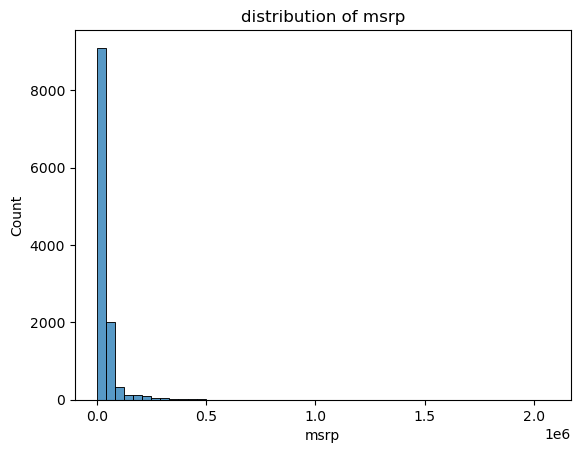

In [385]:
sns.histplot(df.msrp, bins=50)
plt.title("distribution of msrp")
plt.show()

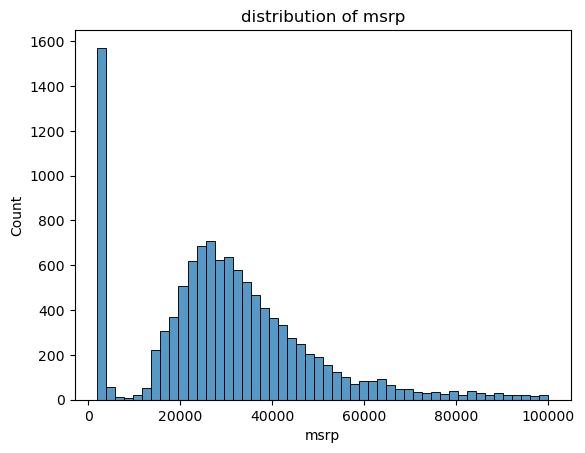

In [386]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)
plt.title("distribution of msrp")
plt.show()

- MSRP → right-skewed distribution with a long tail → apply log transformation for now.

In [387]:
price_logs = np.log1p(df['msrp'])

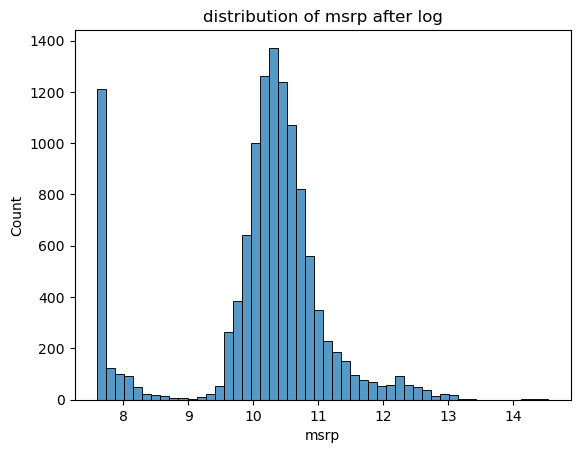

In [388]:
sns.histplot(price_logs, bins=50)
plt.title("distribution of msrp after log")
plt.show()

**Missing values**

In [389]:
df.isna().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

#### 1.3 Setting Up the Validation Framework

In [390]:
# Split the data
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Shuffle the data
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

# Split the data
df_train = df.iloc[idx[:n_train]]
df_test = df.iloc[idx[n_train:n_train + n_test]]
df_val = df.iloc[idx[n_train + n_test:]]

In [391]:
# Reset indices
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [392]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
1,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
2,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120
3,volvo,740,1992,regular_unleaded,114.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,26,18,870,2000
4,ford,crown_victoria,2010,flex-fuel_(unleaded/e85),224.0,8.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,sedan,24,16,5657,29905


In [393]:
df_train.shape , df_test.shape, df_val.shape

((7150, 16), (2382, 16), (2382, 16))

In [394]:
# target
y_train = np.log1p(df_train.msrp.values)
y_test = np.log1p(df_test.msrp.values)
y_val = np.log1p(df_val.msrp.values)

In [395]:
# Delete the target from features
del df_train["msrp"]
del df_test["msrp"]
del df_val["msrp"]

#### 1.4 Linear regression

In [396]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [397]:
xi =[453, 11, 86]
w0 = 7.17
w = [0.01,0.04,0.002]

In [398]:
def linear_regression(xi):
    m = len(xi)
    pred = w0
    for i in range(m):
        pred +=  w[i]*xi[i]
    return pred
linear_regression(xi)

12.312

In [399]:
np.expm1(12.312)

np.float64(222347.2221101062)

#### 1.5  Linear Regression: Vector Form

In [400]:
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x10 = [1,453, 11 ,86]
X = np.array([x1,x2,x10])
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [401]:
w_new = [w0] + w
w_new

[7.17, 0.01, 0.04, 0.002]

In [402]:
def linear_regression(X):
    return X.dot(w_new)
linear_regression(X)

array([12.38 , 13.552, 12.312])

#### 1.6 Training a linear regression model

In [403]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [404]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000] 
y

[10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [405]:
def train_linear_regression(X,y):
    m = X.shape[0]
    ones = np.ones(m)
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [406]:
w0, w = train_linear_regression(X,y)
print("Bias:", w0)
print("Weights:", w)

Bias: 25844.75405576679
Weights: [ -16.08906468 -199.47254894   -1.22802883]


#### 1.7 Car baseline model

In [407]:
base = ["engine_hp", "engine_cylinders","highway_mpg",
        "city_mpg","popularity"]

In [408]:
X_train =df_train[base].fillna(0).values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]])

In [409]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978])

In [410]:
w0 , w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111])

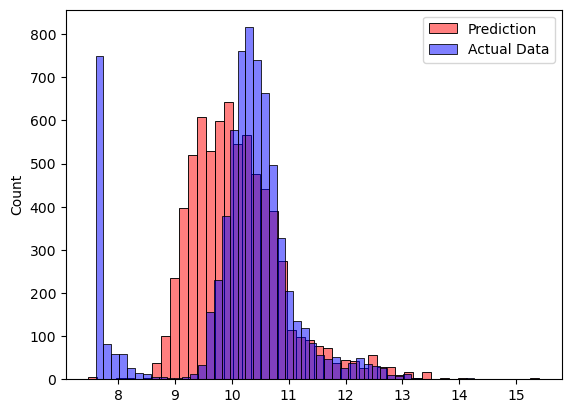

In [411]:
sns.histplot(y_pred, color="r", bins=50, label="Prediction", alpha=0.5)
sns.histplot(y_train, color="blue", bins=50, label="Actual Data", alpha=0.5)

plt.legend()
plt.show()

**This model is not ideal, so to quantify the prediction error, we use RMSE.**

#### 1.8 RMSE

In [412]:
def rmse(y, y_pred):
    se = (y - y_pred)**2
    mse =se.mean()
    return np.sqrt(mse)

In [413]:
# rmse on training data
rmse(y_train,y_pred)

np.float64(0.7554192603920132)

#### 1.9 Validating the model

In [414]:
def prepare_X(df):
    df = df.copy()
    df_num = df[base].fillna(0)
    X = df_num.values
    return X

In [415]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.7359130757318724)

#### 1.10 simple feature engineering

In [416]:
def prepare_X(df):
    df = df.copy()
    df["age"] = 2017 - df.year
    features = base + ["age"]
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [417]:
X_train = prepare_X(df_train)
w0 , w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5149229218585324)

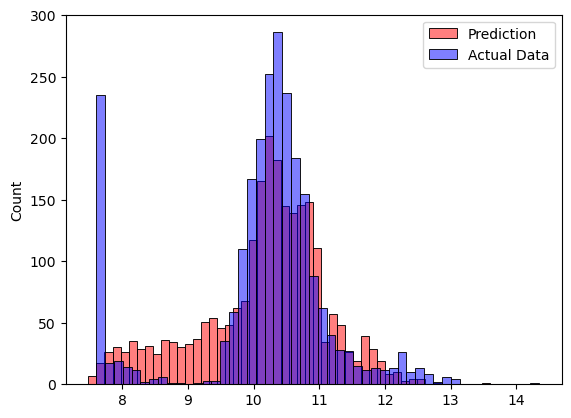

In [418]:
sns.histplot(y_pred, color="r", bins=50, label="Prediction", alpha=0.5)
sns.histplot(y_val, color="blue", bins=50, label="Actual Data", alpha=0.5)

plt.legend()
plt.show()

#### 1.11 Categorical variables

In [419]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)

In [420]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [422]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(657.4121411101564)